# Lab 4: Decision Trees, Exercise 3

| Student | Student ID |
|---|---|
| Brian Ezeanya | 26134667 |
| Joseph Gimba | 25243888 |
| Gloria Ezeanya | 26128756 |

**Objective:** apply a decision tree classifier to the UCI Car Evaluation dataset to predict a car's evaluation class from six categorical features.

| Class | Meaning |
|---|---|
| `unacc` | unacceptable |
| `acc` | acceptable |
| `good` | good |
| `vgood` | very good |

The dataset (`car_evaluation.csv`) was obtained from the UCI ML Repository. The file has no header row, so column names are assigned when it is loaded.

## 1. Import libraries
The first cell installs the required packages (only needed once per environment). The second imports everything used in this notebook.

In [1]:
%pip install pandas matplotlib scikit-learn category_encoders

You should consider upgrading via the '/Users/mac/Downloads/Masters Courses/Machine Learning/Machine_Learning_Exercises/.venv/bin/python -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import category_encoders as ce

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the dataset
The CSV is read into a pandas DataFrame. Each row describes one car; the final column, `class`, is the target variable.

In [3]:
columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

df = pd.read_csv("car_evaluation.csv", names=columns, header=None)
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 3. Exploratory data analysis
We report the shape of the dataset, check for missing values, and compute the mode of each column and the class distribution.

All seven columns are categorical (e.g. `doors` includes the value `5more` and `persons` includes `more`). The mean and median are therefore not meaningful on the raw values, as averaging arbitrary category labels has no interpretation. The mode and frequency counts are used instead.

In [4]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nMost common value in each column:")
print(df.mode().iloc[0])
print("\nNumber of cars in each class:")
print(df["class"].value_counts())

Shape: (1728, 7)

Missing values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Most common value in each column:
buying       high
maint        high
doors           2
persons         2
lug_boot      big
safety       high
class       unacc
Name: 0, dtype: object

Number of cars in each class:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


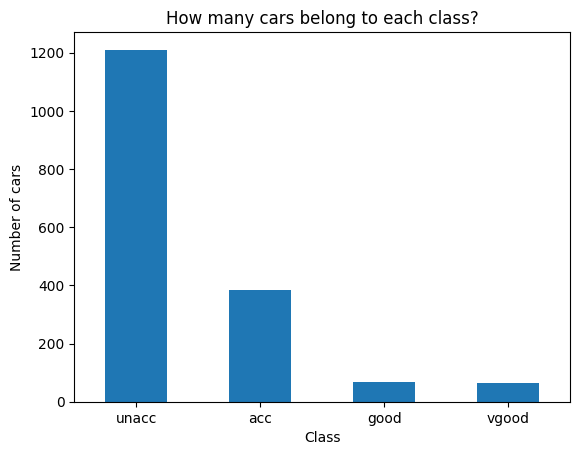

In [5]:
df["class"].value_counts().plot(kind="bar")
plt.title("How many cars belong to each class?")
plt.xlabel("Class")
plt.ylabel("Number of cars")
plt.xticks(rotation=0)
plt.show()

As required, a scatter plot of `safety` against `class` is shown below. Because both axes are categorical, many points overlap, so the cross-tabulation underneath gives a clearer view of the relationship.

**Observation:** every car with `low` safety is rated `unacc`, and `vgood` occurs only with `high` safety. Safety is therefore expected to be a strong splitting feature.

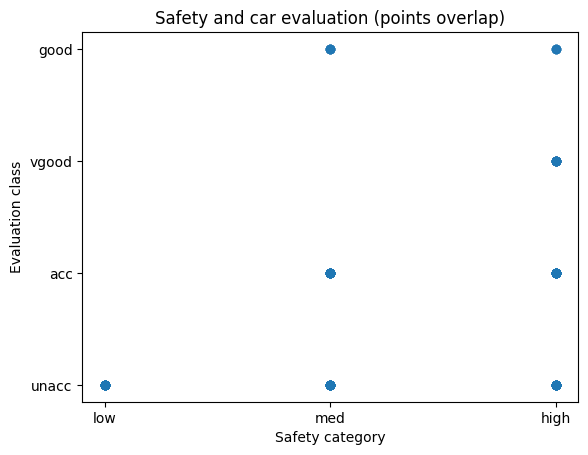

class,acc,good,unacc,vgood
safety,,,,
high,204,30,277,65
low,0,0,576,0
med,180,39,357,0


In [6]:
plt.scatter(df["safety"], df["class"], alpha=0.1)
plt.xlabel("Safety category")
plt.ylabel("Evaluation class")
plt.title("Safety and car evaluation (points overlap)")
plt.show()

pd.crosstab(df["safety"], df["class"])

## 4. Declare the feature vector and target variable
`X` contains the six input features and `y` contains the target `class`. The target is dropped from `X` so the model cannot learn from the label directly.

In [7]:
X = df.drop(columns="class")
y = df["class"]

## 5. Train/test split
The data is split 80% training / 20% test. `random_state=0` makes the split reproducible, and `stratify=y` preserves the class proportions in both sets, which is important given the class imbalance observed in Section 3.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 1382
Test rows: 346


## 6. Encode categorical variables
The features are encoded with `category_encoders.OrdinalEncoder`, as specified in the lab brief. The encoder is fitted on the training set only (`fit_transform`) and the same mapping is applied to the test set (`transform`), which avoids leaking information from the test data.

Note that the default integer codes reflect the order in which categories appear, not necessarily their natural ranking (e.g. `low` < `med` < `high`).

In [9]:
encoder = ce.OrdinalEncoder(cols=X.columns.tolist())

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

X_train.head()

,buying,maint,doors,persons,lug_boot,safety
643,1,1,1,1,1,1
1276,2,2,1,2,2,1
1591,3,3,2,1,2,1
96,4,4,1,3,2,2
1638,3,2,3,1,3,2


## 7. Decision tree with the Gini criterion
A `DecisionTreeClassifier` is trained with `criterion='gini'`, `max_depth=3` and `random_state=0`, then evaluated on both the training and test sets using accuracy.

In [10]:
gini_tree = DecisionTreeClassifier(
    criterion="gini", max_depth=3, random_state=0
)
gini_tree.fit(X_train, y_train)

gini_train_predictions = gini_tree.predict(X_train)
gini_test_predictions = gini_tree.predict(X_test)

print("Training accuracy:", accuracy_score(y_train, gini_train_predictions))
print("Test accuracy:", accuracy_score(y_test, gini_test_predictions))

Training accuracy: 0.7821997105643994
Test accuracy: 0.7427745664739884


## 8. Decision tree with the entropy criterion
The same configuration is trained with `criterion='entropy'`, so splits are chosen by information gain (as computed by hand in Exercises 1 and 2). Both models are compared below.

In [11]:
entropy_tree = DecisionTreeClassifier(
    criterion="entropy", max_depth=3, random_state=0
)
entropy_tree.fit(X_train, y_train)

entropy_train_predictions = entropy_tree.predict(X_train)
entropy_test_predictions = entropy_tree.predict(X_test)

results = pd.DataFrame({
    "Tree": ["Gini", "Entropy"],
    "Training accuracy": [
        accuracy_score(y_train, gini_train_predictions),
        accuracy_score(y_train, entropy_train_predictions)
    ],
    "Test accuracy": [
        accuracy_score(y_test, gini_test_predictions),
        accuracy_score(y_test, entropy_test_predictions)
    ]
})
results

,Tree,Training accuracy,Test accuracy
0,Gini,0.782200,0.742775
1,Entropy,0.776411,0.739884


### Overfitting analysis
Overfitting appears as training accuracy substantially higher than test accuracy. Here the gap is small for both models (Gini: 0.782 vs 0.743; entropy: 0.776 vs 0.740), so **there is no meaningful sign of overfitting**. The Gini tree is marginally better on the test set, but the difference of about 0.3 percentage points is negligible.

A small gap alone does not mean the model is good. Because the classes are imbalanced, we compare against a majority-class baseline that always predicts the most frequent training class.

In [12]:
most_common_class = y_train.mode()[0]
baseline_accuracy = (y_test == most_common_class).mean()
print("Always predict:", most_common_class)
print("Baseline test accuracy:", baseline_accuracy)

Always predict: unacc
Baseline test accuracy: 0.6994219653179191


The majority-class baseline achieves 0.699 test accuracy, so both trees improve on it by only about 4 percentage points.

## 9. Confusion matrix
The confusion matrix for the entropy tree on the test set is shown below. Rows are actual classes and columns are predicted classes; diagonal entries are correct predictions.

In [13]:
class_labels = entropy_tree.classes_

cm = confusion_matrix(y_test, entropy_test_predictions, labels=class_labels)
pd.DataFrame(
    cm,
    index=["Actual " + label for label in class_labels],
    columns=["Predicted " + label for label in class_labels]
)

,Predicted acc,Predicted good,Predicted unacc,Predicted vgood
Actual acc,34,0,43,0
Actual good,6,0,8,0
Actual unacc,20,0,222,0
Actual vgood,13,0,0,0


**Interpretation:** the predicted `good` and `vgood` columns are entirely zero, so the tree never predicts either class. All 13 `vgood` cars are misclassified as `acc`, and 43 of the 77 `acc` cars are misclassified as `unacc`.

## 10. Classification report
- **Precision:** of the cars predicted as a class, the proportion that truly belong to it.
- **Recall:** of the cars that truly belong to a class, the proportion the model identified.
- **F1-score:** the harmonic mean of precision and recall.
- **Support:** the number of test samples in each class.

`zero_division=0` reports 0 instead of a warning when a metric is undefined (e.g. precision for a class that is never predicted).

In [14]:
print(classification_report(
    y_test, entropy_test_predictions, zero_division=0
))

              precision    recall  f1-score   support

         acc       0.47      0.44      0.45        77
        good       0.00      0.00      0.00        14
       unacc       0.81      0.92      0.86       242
       vgood       0.00      0.00      0.00        13

    accuracy                           0.74       346
   macro avg       0.32      0.34      0.33       346
weighted avg       0.67      0.74      0.70       346



**Interpretation:** the model performs well on the majority class `unacc` (recall 0.92) but obtains zero precision and recall for `good` and `vgood`. The overall accuracy of 0.74 is driven by the dominant class, and the macro-averaged F1-score (0.33) gives a more honest picture of performance across all four classes.

## Decision tree visualisation
The fitted entropy tree is plotted below using `sklearn.tree.plot_tree` (an alternative to graphviz). At each node the left branch is followed when the condition is true. Thresholds refer to the ordinal-encoded values from Section 6, and each node shows its majority class.

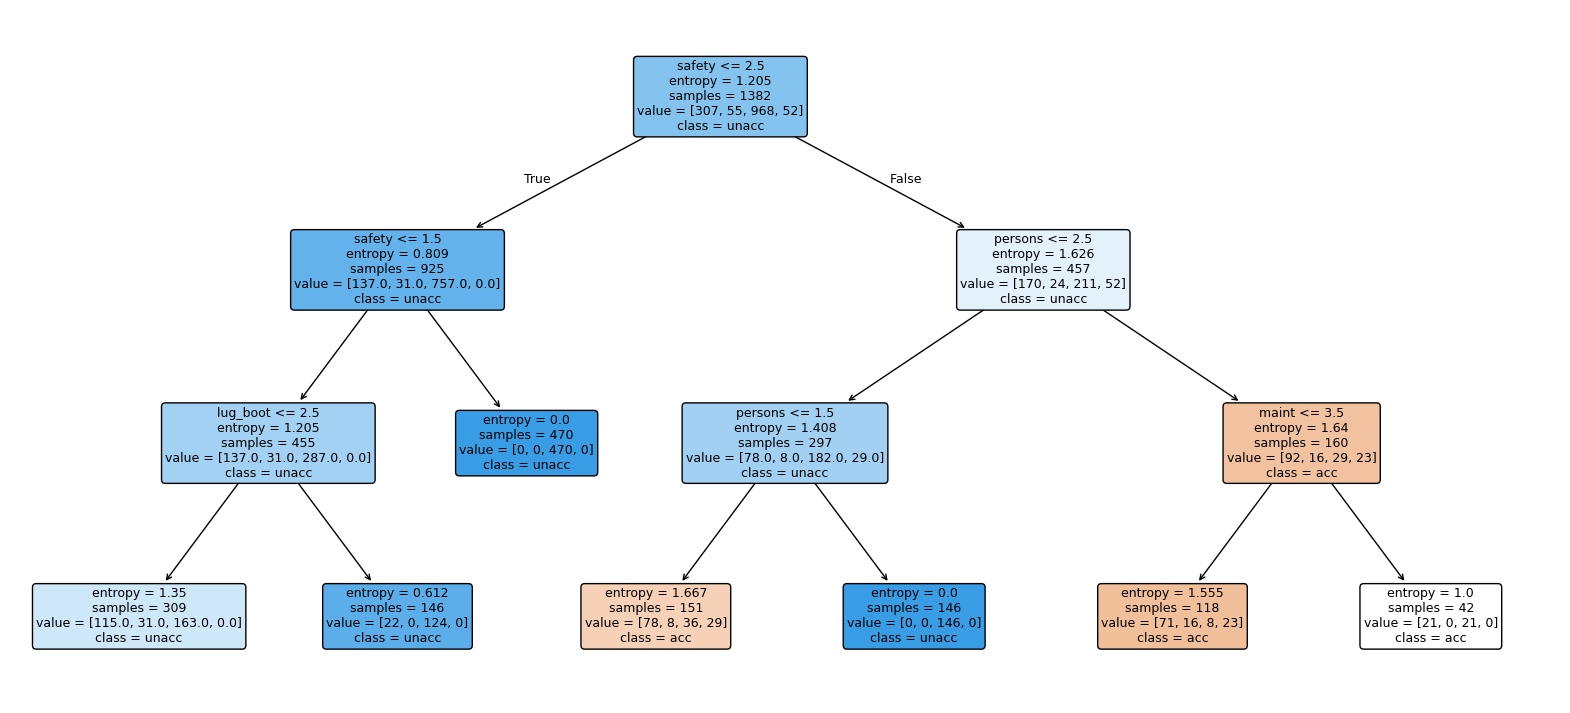

In [15]:
plt.figure(figsize=(20, 9))
plot_tree(
    entropy_tree,
    feature_names=X.columns.tolist(),
    class_names=entropy_tree.classes_.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

## Conclusions
1. **Gini vs entropy:** both criteria perform almost identically at `max_depth=3` (test accuracy 0.743 vs 0.740). The choice of criterion has little effect on this dataset.
2. **Overfitting:** the train/test gap is roughly 4 percentage points for both models, so there is no evidence of overfitting.
3. **Underfitting and class imbalance:** test accuracy is only about 4 points above the majority-class baseline (0.699). The confusion matrix and classification report show that the tree never predicts `good` or `vgood` (recall 0.00), and recall for `acc` is only 0.44. A depth-3 tree is too shallow to separate the minority classes, so the model **underfits** rather than overfits.
4. **Possible improvements:** tuning `max_depth`, `min_samples_leaf` and related hyperparameters with cross-validation, using `class_weight='balanced'` to address the imbalance, and supplying an explicit category order to the ordinal encoder so the integer codes reflect each feature's natural ranking.